<a href="https://colab.research.google.com/github/batu-uchicago/bayes-applications/blob/main/Bayes%20Nets/BayesNets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The student Bayes net

For more info: https://github.com/pgmpy/pgmpy_notebook/blob/master/notebooks/2.%20Bayesian%20Networks.ipynb

### 1. Setup

Run the cell below once.
It checks that Graphviz, which draws the networks, is installed.
On Colab it also installs pgmpy and downloads `pgm_utils.py`, the drawing helpers that sit next to this notebook.

In [1]:
# On your laptop, `pip install -r requirements.txt` (see the README) has installed everything.
# On Colab, this installs pgmpy and downloads the drawing helpers.
import shutil, subprocess, sys, urllib.request

if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pgmpy>=1.1.2,<1.3"], check=True)
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/batu-uchicago/bayes-applications/main/Bayes%20Nets/pgm_utils.py",
        "pgm_utils.py")

if shutil.which("dot") is None:
    print("Graphviz is missing, so the figures below will fail. Install it as the README says, then restart the kernel.")
else:
    print("Setup complete.")

Setup complete.


In [2]:
import warnings

# requirements.txt keeps pgmpy below 1.3, so hide its notices about classes that move in 1.3.
warnings.filterwarnings("ignore", message=r".*will be removed in v1\.3\.0", category=FutureWarning)

import numpy as np
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

import pgm_utils as pgm  # drawing helpers, in the same folder as this notebook

# Model



<img src="https://user-images.githubusercontent.com/4632336/118884310-21bec180-b8ab-11eb-81cf-481553c21d8a.png?raw=true">


In [3]:
# Define the model structure

model = DiscreteBayesianNetwork([('Diff', 'Grade'), ('Intel', 'Grade'), ('Grade', 'Letter'), ('Intel', 'SAT')])


## Basic CPTs

In [4]:
# Defining individual CPDs.
cpd_d = TabularCPD(variable="Diff", variable_card=2, values=[[0.6], [0.4]])
cpd_i = TabularCPD(variable="Intel", variable_card=2, values=[[0.7], [0.3]])

# The representation of CPD in pgmpy is a bit different than the CPD shown in the above picture. In pgmpy the colums
# are the evidences and rows are the states of the variable. So the grade CPD is represented like this:
#
#    +---------+---------+---------+---------+---------+
#    | diff    | intel_0 | intel_0 | intel_1 | intel_1 |
#    +---------+---------+---------+---------+---------+
#    | intel   | diff_0  | diff_1  | diff_0  | diff_1  |
#    +---------+---------+---------+---------+---------+
#    | grade_0 | 0.3     | 0.05    | 0.9     | 0.5     |
#    +---------+---------+---------+---------+---------+
#    | grade_1 | 0.4     | 0.25    | 0.08    | 0.3     |
#    +---------+---------+---------+---------+---------+
#    | grade_2 | 0.3     | 0.7     | 0.02    | 0.2     |
#    +---------+---------+---------+---------+---------+

cpd_g = TabularCPD(
    variable="Grade",
    variable_card=3,
    values=[[0.3, 0.05, 0.9, 0.5], [0.4, 0.25, 0.08, 0.3], [0.3, 0.7, 0.02, 0.2]],
    evidence=["Intel", "Diff"],
    evidence_card=[2, 2],
)

cpd_l = TabularCPD(
    variable="Letter",
    variable_card=2,
    values=[[0.1, 0.4, 0.99], [0.9, 0.6, 0.01]],
    evidence=["Grade"],
    evidence_card=[3],
)

cpd_s = TabularCPD(
    variable="SAT", variable_card=2, values=[[0.95, 0.2], [0.05, 0.8]], evidence=["Intel"], evidence_card=[2]
)

# Associating the CPDs with the network
model.add_cpds(cpd_d, cpd_i, cpd_g, cpd_l, cpd_s)

# check_model checks for the network structure and CPDs and verifies that the CPDs are correctly
# defined and sum to 1.
model.check_model()

True

In [5]:
print(model.get_cpds("Grade"))

+----------+----------+----------+----------+----------+
| Intel    | Intel(0) | Intel(0) | Intel(1) | Intel(1) |
+----------+----------+----------+----------+----------+
| Diff     | Diff(0)  | Diff(1)  | Diff(0)  | Diff(1)  |
+----------+----------+----------+----------+----------+
| Grade(0) | 0.3      | 0.05     | 0.9      | 0.5      |
+----------+----------+----------+----------+----------+
| Grade(1) | 0.4      | 0.25     | 0.08     | 0.3      |
+----------+----------+----------+----------+----------+
| Grade(2) | 0.3      | 0.7      | 0.02     | 0.2      |
+----------+----------+----------+----------+----------+


## CPDs with names states

In [6]:
# CPDs can also be defined using the state names of the variables. If the state names are not provided
# like in the previous example, pgmpy will automatically assign names as: 0, 1, 2, ....

cpd_d_sn = TabularCPD(variable="Diff", variable_card=2, values=[[0.6], [0.4]], state_names={"Diff": ["Easy", "Hard"]})
cpd_i_sn = TabularCPD(variable="Intel", variable_card=2, values=[[0.7], [0.3]], state_names={"Intel": ["Low", "High"]})
cpd_g_sn = TabularCPD(
    variable="Grade",
    variable_card=3,
    values=[[0.3, 0.05, 0.9, 0.5], [0.4, 0.25, 0.08, 0.3], [0.3, 0.7, 0.02, 0.2]],
    evidence=["Intel", "Diff"],
    evidence_card=[2, 2],
    state_names={"Grade": ["A", "B", "C"], "Intel": ["Low", "High"], "Diff": ["Easy", "Hard"]},
)

cpd_l_sn = TabularCPD(
    variable="Letter",
    variable_card=2,
    values=[[0.1, 0.4, 0.99], [0.9, 0.6, 0.01]],
    evidence=["Grade"],
    evidence_card=[3],
    state_names={"Letter": ["Bad", "Good"], "Grade": ["A", "B", "C"]},
)

cpd_s_sn = TabularCPD(
    variable="SAT",
    variable_card=2,
    values=[[0.95, 0.2], [0.05, 0.8]],
    evidence=["Intel"],
    evidence_card=[2],
    state_names={"SAT": ["Bad", "Good"], "Intel": ["Low", "High"]},
)

# These defined CPDs can be added to the model. Since, the model already has CPDs associated to variables, it will
# show warning that pmgpy is now replacing those CPDs with the new ones.
model.add_cpds(cpd_d_sn, cpd_i_sn, cpd_g_sn, cpd_l_sn, cpd_s_sn)
model.check_model()

True

In [7]:
# Printing a CPD with it's state names defined.
print(model.get_cpds("Grade"))

+----------+------------+------------+-------------+-------------+
| Intel    | Intel(Low) | Intel(Low) | Intel(High) | Intel(High) |
+----------+------------+------------+-------------+-------------+
| Diff     | Diff(Easy) | Diff(Hard) | Diff(Easy)  | Diff(Hard)  |
+----------+------------+------------+-------------+-------------+
| Grade(A) | 0.3        | 0.05       | 0.9         | 0.5         |
+----------+------------+------------+-------------+-------------+
| Grade(B) | 0.4        | 0.25       | 0.08        | 0.3         |
+----------+------------+------------+-------------+-------------+
| Grade(C) | 0.3        | 0.7        | 0.02        | 0.2         |
+----------+------------+------------+-------------+-------------+


In [8]:
for cpd in model.get_cpds():
    print(cpd)

+------------+-----+
| Diff(Easy) | 0.6 |
+------------+-----+
| Diff(Hard) | 0.4 |
+------------+-----+
+-------------+-----+
| Intel(Low)  | 0.7 |
+-------------+-----+
| Intel(High) | 0.3 |
+-------------+-----+
+----------+------------+------------+-------------+-------------+
| Intel    | Intel(Low) | Intel(Low) | Intel(High) | Intel(High) |
+----------+------------+------------+-------------+-------------+
| Diff     | Diff(Easy) | Diff(Hard) | Diff(Easy)  | Diff(Hard)  |
+----------+------------+------------+-------------+-------------+
| Grade(A) | 0.3        | 0.05       | 0.9         | 0.5         |
+----------+------------+------------+-------------+-------------+
| Grade(B) | 0.4        | 0.25       | 0.08        | 0.3         |
+----------+------------+------------+-------------+-------------+
| Grade(C) | 0.3        | 0.7        | 0.02        | 0.2         |
+----------+------------+------------+-------------+-------------+
+--------------+----------+----------+----------

# Inference

In [9]:
# Doing exact inference using Variable Elimination
infer = VariableElimination(model)

## Posterior given Grade=C

In [10]:
evidence = {"Grade": "C"}
postD = infer.query(["Diff"], evidence=evidence).values
postI = infer.query(["Intel"], evidence=evidence).values

print("\n")
print("Pr(Difficulty=Hard|Grade=C) = {:0.2f}".format(postD[1]))
print("Pr(Intelligence=High|Grade=C) = {:0.2f}".format(postI[1]))



Pr(Difficulty=Hard|Grade=C) = 0.63
Pr(Intelligence=High|Grade=C) = 0.08


## Posterior given Grade=C, SAT=Good

In [11]:
evidence = {"Grade": "C", "SAT": "Good"}
postD = infer.query(["Diff"], evidence=evidence).values
postI = infer.query(["Intel"], evidence=evidence).values

print("\n")
print("Pr(Difficulty=Hard|Grade=C,SAT=Good) = {:0.2f}".format(postD[1]))
print("Pr(Intelligence=High|Grade=C,SAT=Good) = {:0.2f}".format(postI[1]))



Pr(Difficulty=Hard|Grade=C,SAT=Good) = 0.76
Pr(Intelligence=High|Grade=C,SAT=Good) = 0.58


# Visualization

## DAG

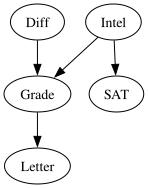

In [12]:
display(pgm.draw_dag(model))

## CPTs

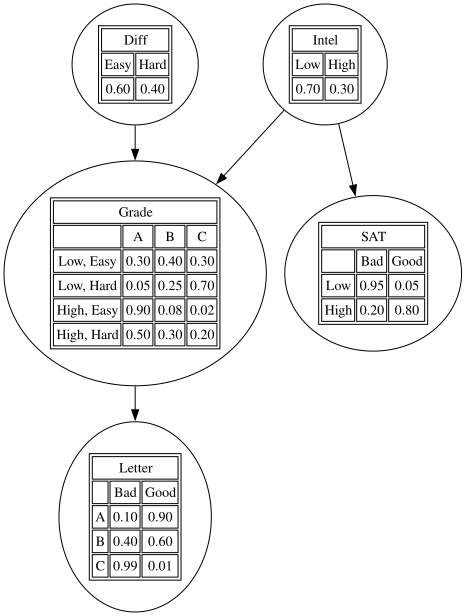

In [13]:
display(pgm.visualize_model(model))

## Marginals

In [14]:
evidence = {"Grade": "C"}
marginals = pgm.get_marginals(model, evidence)
print(marginals)

{'Diff': array([0.37070938, 0.62929062]), 'Grade': array([0., 0., 1.]), 'Intel': array([0.92105263, 0.07894737]), 'Letter': array([0.99, 0.01]), 'SAT': array([0.89078947, 0.10921053])}


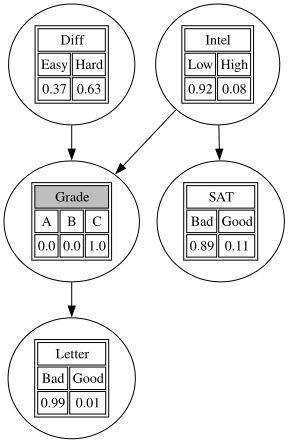

In [15]:
display(pgm.visualize_marginals(model, evidence, marginals))

{'Diff': array([0.24044002, 0.75955998]), 'Grade': array([0., 0., 1.]), 'Intel': array([0.42168675, 0.57831325]), 'Letter': array([0.99, 0.01]), 'SAT': array([0., 1.])}


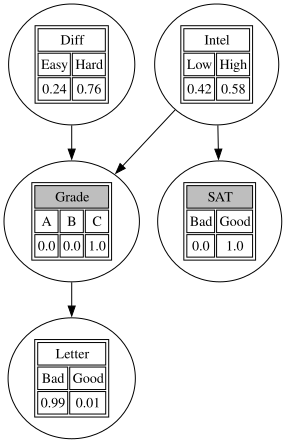

In [16]:
evidence = {"Grade": "C", "SAT": "Good"}
marginals = pgm.get_marginals(model, evidence)
print(marginals)

display(pgm.visualize_marginals(model, evidence, marginals))

In [17]:
# Let's check the independencies in the model.
model.get_independencies()

(Diff ⟂ SAT)
(Diff ⟂ Letter | Grade)
(Letter ⟂ SAT | Intel)
(Diff ⟂ Intel)
(Grade ⟂ SAT | Intel)
(Intel ⟂ Letter | Grade)

In [18]:
# Sample data from the model. The seed fixes the sample, so every run gives the same
# results; change it to see how the structure learning below changes.
from pgmpy.sampling import BayesianModelSampling

SEED = 3
data = BayesianModelSampling(model).forward_sample(10000, seed=SEED, show_progress=False)

In [19]:
print(f"{len(data):,} samples of {data.shape[1]} variables")
data.head(10)

10,000 samples of 5 variables


,Diff,Grade,Intel,Letter,SAT
0,Easy,A,Low,Good,Bad
1,Hard,A,High,Good,Good
2,Easy,A,High,Good,Good
3,Easy,A,Low,Good,Bad
4,Hard,C,Low,Bad,Bad
5,Hard,C,Low,Bad,Bad
6,Easy,C,Low,Bad,Bad
7,Easy,C,Low,Bad,Bad
8,Easy,A,Low,Good,Bad
9,Easy,A,High,Good,Bad


## Hillclimb Algorithm (can be iffy)

Exhaustive search scores every possible DAG on these five variables, all 29,281 of them (about 10 seconds), and keeps the best.
Hill climbing starts from an empty graph and keeps making the one change (add, remove or reverse an edge) that improves the score most.
It is fast, but it can stop at a local optimum.

In [20]:
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch
from pgmpy.structure_score import get_scoring_method

# pgmpy >= 1.1 names scoring methods with strings: 'bic-d' is BIC for discrete data.
est_hill = HillClimbSearch(data)
est_exhaustive = ExhaustiveSearch(data, scoring_method='bic-d')

best_hill_model = est_hill.estimate(scoring_method='bic-d', show_progress=False)
best_exhaustive_model = est_exhaustive.estimate()

print("HillClimb edges: ", sorted(best_hill_model.edges()))
print("Exhaustive edges:", sorted(best_exhaustive_model.edges()))
print("True edges:      ", sorted(model.edges()))

HillClimb edges:  [('Grade', 'Diff'), ('Grade', 'Intel'), ('Grade', 'SAT'), ('Intel', 'Diff'), ('Letter', 'Grade'), ('SAT', 'Intel')]
Exhaustive edges: [('Diff', 'Grade'), ('Grade', 'Letter'), ('Intel', 'Grade'), ('Intel', 'SAT')]
True edges:       [('Diff', 'Grade'), ('Grade', 'Letter'), ('Intel', 'Grade'), ('Intel', 'SAT')]


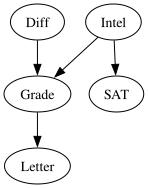

In [21]:
# The structure exhaustive search found
display(pgm.draw_dag(best_exhaustive_model))

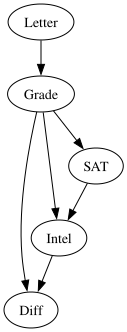

In [22]:
# The structure hill climbing found
display(pgm.draw_dag(best_hill_model))

# How to fit model to data?

In [23]:
from pgmpy.estimators import MaximumLikelihoodEstimator

# Give the structure exhaustive search found its tables, estimated from the data by maximum likelihood.
network_exh = DiscreteBayesianNetwork(best_exhaustive_model)
mle = MaximumLikelihoodEstimator(network_exh, data)
for cpd in mle.get_parameters():
    network_exh.add_cpds(cpd)

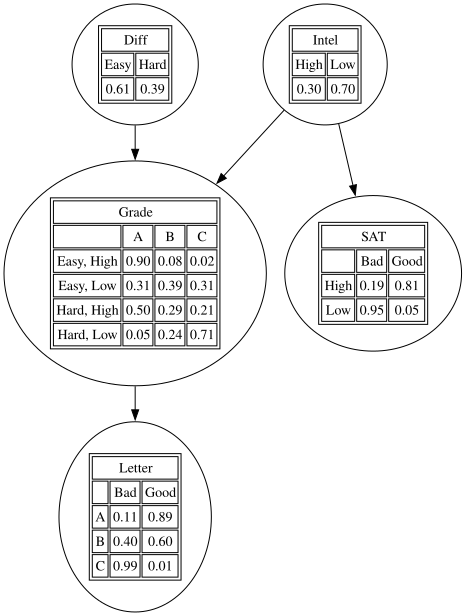

In [24]:
display(pgm.visualize_model(network_exh))

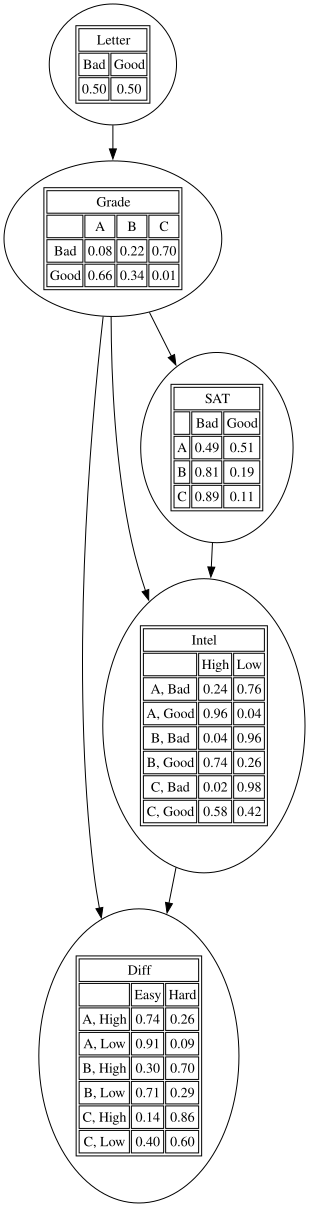

In [25]:
# Do the same for the hill climb model
network_hill = DiscreteBayesianNetwork(best_hill_model)
mle = MaximumLikelihoodEstimator(network_hill, data)
for cpd in mle.get_parameters():
    network_hill.add_cpds(cpd)

display(pgm.visualize_model(network_hill))

## Comparing Models

In [26]:
# Compare the BIC score of the two learned structures on the data.
# pgmpy's BIC is the log-likelihood minus a penalty for every parameter, so higher is better.
scorer = get_scoring_method('bic-d', data)
exh_score = scorer.score(network_exh)
hill_score = scorer.score(network_hill)

print(f"Exhaustive (BIC): {exh_score:.2f}")
print(f"HillClimb  (BIC): {hill_score:.2f}")
print()
print("Same DAG:         ", set(network_exh.edges()) == set(network_hill.edges()))
print("Markov equivalent:", network_exh.is_iequivalent(network_hill))

Exhaustive (BIC): -27641.00
HillClimb  (BIC): -27662.24

Same DAG:          False
Markov equivalent: False


Exhaustive search tries every DAG, so its score is the best possible; hill climbing can only tie it or fall short.
With `SEED = 3`, hill climbing stops at a local optimum, a six-edge graph that scores worse.

Different DAGs can also score exactly the same.
Two DAGs with the same skeleton and the same v-structures are *Markov equivalent*: they encode the same independencies, so they fit any data equally well and get the same BIC.
Set `SEED = 1` and rerun: hill climbing returns `SAT → Intel` instead of `Intel → SAT`, the scores tie, and no amount of data can tell the two apart.

## When data are thin: Laplace smoothing

Maximum likelihood trusts the counts completely, so a combination missing from the data gets probability 0.
With 10,000 samples that rarely happens, so here we fit `Grade`'s table on the first 30 rows only.
Find the parent combination with the fewest students, and compare its row under the two estimates.

Laplace smoothing adds one imaginary observation of every grade to every row before dividing.
In pgmpy that is `BayesianEstimator` with `prior_type="K2"`.

In [27]:
from pgmpy.estimators import BayesianEstimator

small = data.head(30)
structure = DiscreteBayesianNetwork(model.edges())

# model.states lists every state, so a grade missing from the 30 rows still gets a column.
mle_grade = MaximumLikelihoodEstimator(structure, small, state_names=model.states).estimate_cpd("Grade")
laplace_grade = BayesianEstimator(structure, small, state_names=model.states).estimate_cpd("Grade", prior_type="K2")

print("Counts:")
display(pd.crosstab([small[v] for v in mle_grade.variables[1:]], small.Grade))
print("Maximum likelihood:")
display(mle_grade.to_dataframe().round(2))
print("Laplace smoothing:")
display(laplace_grade.to_dataframe().round(2))

Counts:


Grade       A  B  C
Diff Intel         
Easy High   5  1  0
     Low    4  5  7
Hard High   1  0  0
     Low    1  1  5

Maximum likelihood:


Grade          A     B     C
Diff Intel                  
Easy High   0.83  0.17  0.00
     Low    0.25  0.31  0.44
Hard High   1.00  0.00  0.00
     Low    0.14  0.14  0.71

Laplace smoothing:


Grade          A     B     C
Diff Intel                  
Easy High   0.67  0.22  0.11
     Low    0.26  0.32  0.42
Hard High   0.50  0.25  0.25
     Low    0.20  0.20  0.60